|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Words to tokens to numbers<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: Create and visualize tokens<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

# adjust matplotlib defaults to personal preferences
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Exercise 1: Make encoder and decoder functions

In [2]:
# list of sentences
text = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ]

# create a vocab of unique words
allwords = re.split(r'\s',' '.join(text).lower())
vocab = sorted(set(allwords)) # the sorted unique words

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [3]:
# create an encoder and decoder dictionaries
word2idx = { word:i for i,word in enumerate(vocab) }
idx2word = { i:word for i,word in enumerate(vocab) }
word2idx

{'all': 0,
 'already': 1,
 'are': 2,
 'be': 3,
 'else': 4,
 'everyone': 5,
 'have': 6,
 'is': 7,
 'not': 8,
 'of': 9,
 'or': 10,
 'question': 11,
 'result': 12,
 'taken': 13,
 'that': 14,
 'the': 15,
 'thought': 16,
 'to': 17,
 'we': 18,
 'what': 19,
 'yourself': 20}

In [4]:
word2idx

{'all': 0,
 'already': 1,
 'are': 2,
 'be': 3,
 'else': 4,
 'everyone': 5,
 'have': 6,
 'is': 7,
 'not': 8,
 'of': 9,
 'or': 10,
 'question': 11,
 'result': 12,
 'taken': 13,
 'that': 14,
 'the': 15,
 'thought': 16,
 'to': 17,
 'we': 18,
 'what': 19,
 'yourself': 20}

In [5]:
{v:k for v,k in word2idx.items()}

{'all': 0,
 'already': 1,
 'are': 2,
 'be': 3,
 'else': 4,
 'everyone': 5,
 'have': 6,
 'is': 7,
 'not': 8,
 'of': 9,
 'or': 10,
 'question': 11,
 'result': 12,
 'taken': 13,
 'that': 14,
 'the': 15,
 'thought': 16,
 'to': 17,
 'we': 18,
 'what': 19,
 'yourself': 20}

# Exercise 2: Wrap the encoder/decoder into functions

In [6]:
### the encoder function
def encoder(text):

  # parse the text into words
  words = re.split(r'\s',text.lower())
  # return the vector of indices
  return [word2idx[w] for w in words]


### now for the decoder
def decoder(indices):

  # find the words for these indices, and join into one string
  return ' '.join([idx2word[index] for index in indices])

In [7]:
# reminder of the available words
print(vocab)

['all', 'already', 'are', 'be', 'else', 'everyone', 'have', 'is', 'not', 'of', 'or', 'question', 'result', 'taken', 'that', 'the', 'thought', 'to', 'we', 'what', 'yourself']


In [8]:
# create a new sentence using the vocab
newtext = 'we already are the result of what ' \
          'everyone else already thought'

newtext_tokenIDs = encoder(newtext)
decoded_text = decoder(newtext_tokenIDs)

print('Original text:')
print(f'\t{newtext}')

print(f'\nToken IDs:')
print(f'\t{newtext_tokenIDs}')

print(f'\nDecoded text:')
print(f'\t{decoded_text}')

Original text:
	we already are the result of what everyone else already thought

Token IDs:
	[18, 1, 2, 15, 12, 9, 19, 5, 4, 1, 16]

Decoded text:
	we already are the result of what everyone else already thought


# Exercise 3: Visualize the tokens

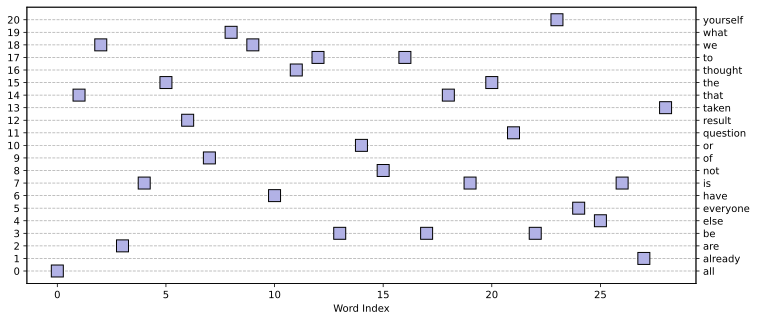

In [9]:
# get all the text and all the tokens
alltext = ' '.join(text)
tokens = encoder(alltext)

# create a figure
_,ax = plt.subplots(1,figsize=(12,5))

# plot the tokens
ax.plot(tokens,'ks',markersize=12,markerfacecolor=[.7,.7,.9])
ax.set(xlabel='Word Index',yticks=range(len(vocab)))
ax.grid(linestyle='--',axis='y')

# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens,alpha=0)
ax2.set(yticks=range(len(vocab)),yticklabels=vocab)

plt.show()

# Exercise 4: Explore context surrounding target tokens

In [10]:
# what words are in the context of "to"

targetWord = 'to'
targetIdx = word2idx[targetWord] # the index of this word in the vocab

# find indices
targetLocs = np.where(np.asarray(tokens) == targetIdx)[0]
print(f'"{targetWord}" appears at indices {targetLocs}\n\n')

# print context
for t in targetLocs:
  print(tokens[t-1:t+2]) # token indices
  print() # token strings

"to" appears at indices [12 16]


[16, 17, 3]

[8, 17, 3]



# Exercise 5: One-hot encoding

In [18]:
word_matrix = np.zeros((len(tokens),len(vocab)),dtype=int)

# create the matrix
for i,word in enumerate(allwords):
  word_matrix[i,word2idx[word]] = 1

# show the results
print(f'One-hot encoding matrix is of size {word_matrix.shape}\n')
print(word_matrix)

One-hot encoding matrix is of size (29, 21)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 

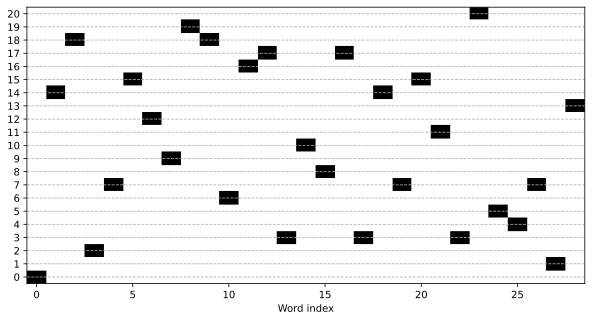

In [21]:
# the image of the one-hot encoding matrix is the same as in Exercise 2
_,ax = plt.subplots(1,figsize=(10,5))

plt.imshow(1-word_matrix.T,cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel='Word index',yticks=range(len(vocab)))
ax.grid(linestyle='--',axis='y')
plt.show()